In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# On-Policy, Off-Policy, and Offline Learning

On-policy estimators require data from the current policy, whereas off-policy value methods can use transitions collected by other policies. This distinction determines whether a batch may be reused and whether learning from a fixed dataset is possible. We first compare the Q-learning and SARSA targets to make the distinction explicit.

In *offline reinforcement learning*, the agent receives a fixed dataset and cannot collect additional transitions. Errors on poorly covered actions are therefore not corrected by subsequent interaction. Using tabular FrozenLake, where the optimal value is known, we measure this extrapolation error and examine a count-based pessimistic penalty. The example also clarifies the difference between improving predicted value and improving the policy's delivered return.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import gymnasium as gym
import numpy as np

## On-Policy and Off-Policy Updates

### The Two Families of Update Rules

The update rules of the last two chapters fall into two families. A policy gradient is an expectation under the current policy's trajectory distribution, so samples from another policy generally estimate a different quantity. REINFORCE and actor-critic are therefore *on-policy*; PPO permits limited reuse by correcting action probabilities. By contrast, the Q-learning target $r + \gamma \max_{a'} \hat{Q}(s', a')$ depends on the environment transition but not on the policy that selected $a$. A transition collected by an earlier policy, another agent, or a fixed log is therefore a valid sample of the same Bellman backup. This is *off-policy* learning. the figure compares these cases with the offline setting introduced below.

![Three data regimes. On-policy methods estimate expectations under the current policy; reusing older batches requires a change-of-measure correction such as PPO's ratios. Off-policy Bellman targets do not explicitly contain the behavior policy, although learning still requires coverage of the target policy's relevant state--action pairs. Offline learning uses a fixed dataset and cannot collect new transitions to test actions selected by the learned policy.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-data-rules.svg)

### SARSA: Bootstrapping on the Action Taken

SARSA differs from Q-learning in the action used for bootstrapping. In the update from the equation, replace the best action at $s'$ by the action $a'$ actually selected by the behavior policy:

$$\delta_{\textrm{SARSA}} = r + \gamma\, Q(s', a') - Q(s, a),$$

The quintuple $(s,a,r,s',a')$ gives SARSA its name
[@Rummery.Niranjan.1994]. In the figure, its update is panel
(d) without the arc denoting maximization: the target follows the sampled
action $a'$.

Averaging this target over $a'\sim\pi_e(\cdot\mid s')$ yields the Bellman
expectation backup for the behavior policy $\pi_e$. For a stationary behavior
policy, SARSA therefore converges to $Q^{\pi_e}$, whereas Q-learning targets
$Q^*$ independently of the behavior policy. During learning, our
$\epsilon$-greedy behavior changes with the table, so we compare the final
table with the value of the final frozen policy. The following implementation
runs both algorithms on the slippery lake with $\epsilon=0.3$; only the
bootstrap action differs:

In [2]:
gamma, epsilon = 0.95, 0.3            # discount; the fixed exploration rate
num_episodes, num_datasets = 500, 15  # episodes per dataset; dataset draws
num_sweeps, alpha, kappa = 200, 0.2, 0.1  # offline sweeps; step; pessimism
env = gym.make('FrozenLake-v1', is_slippery=True)
mdp = d2l.TabularMDP.from_gym(env, gamma)

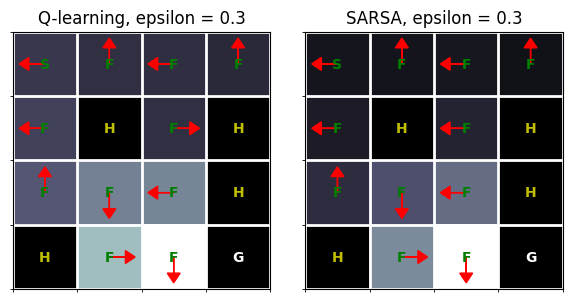

In [3]:
def td_control(seed, env, num_episodes, epsilon, on_policy):
    """Q-learning and SARSA in one loop: they differ in a single symbol."""
    rng = np.random.default_rng(seed)
    Q, visits = np.zeros((16, 4)), np.zeros((16, 4))
    env.reset(seed=seed)
    for _ in range(num_episodes):
        s, done = env.reset()[0], False
        a = d2l.epsilon_greedy(Q[s], epsilon, rng)
        while not done:
            s2, r, terminated, truncated, _ = env.step(a)
            a2 = d2l.epsilon_greedy(Q[s2], epsilon, rng)
            target = Q[s2, a2] if on_policy else Q[s2].max()  # the symbol
            visits[s, a] += 1
            Q[s, a] += (r + gamma * (1 - terminated) * target
                        - Q[s, a]) / (1 + 0.1 * visits[s, a])
            s, a, done = s2, a2, terminated or truncated
    return Q

Q_q = td_control(0, env, 8000, epsilon, on_policy=False)
Q_sarsa = td_control(0, env, 8000, epsilon, on_policy=True)
d2l.show_grid(env.unwrapped.desc, np.stack([Q_q.max(-1), Q_sarsa.max(-1)]),
              np.stack([Q_q.argmax(-1), Q_sarsa.argmax(-1)]),
              titles=['Q-learning, epsilon = 0.3', 'SARSA, epsilon = 0.3'])

The greedy policies differ only at state $6$, where the two symmetric actions
have equal optimal value as discussed in that section. Their value
tables nevertheless represent different quantities. Q-learning estimates
$0.182$ at the start, close to the optimal value $V^*(s_0)=0.180$. SARSA's
largest start-state entry is $0.062$ because its continuation includes
$\epsilon$-greedy exploration, which sometimes moves toward a hole.

Since SARSA estimates $Q^{\pi_e}$, its start-state value is not
$\max_a Q(s_0,a)$ but the policy-weighted average
$\sum_a\pi_e(a\mid s_0)Q(s_0,a)$. The following evaluation compares each
table with the policy whose return it is intended to predict:

In [4]:
env.reset(seed=1)
rng = np.random.default_rng(1)
for name, Q in [('Q-learning', Q_q), ('SARSA', Q_sarsa)]:
    greedy = d2l.evaluate(env, lambda s, r_: int(Q[s].argmax()), 1000)
    earned = d2l.evaluate(env, lambda s, r_: d2l.epsilon_greedy(
        Q[s], epsilon, r_), 1000, gamma, rng)
    claim = (1 - epsilon) * Q[0].max() + epsilon * Q[0].mean()
    print(f'{name:>10}: greedy policy succeeds {greedy:.1%}; '
          f'the behavior earns {earned:.3f}')
    print(f'{"":>10}  the policy-weighted table value '
          f'sum_a pi(a|s0) Q(s0, a) claims {claim:.3f}')

Q-learning: greedy policy succeeds 72.5%; the behavior earns 0.061
            the policy-weighted table value sum_a pi(a|s0) Q(s0, a) claims 0.180


     SARSA: greedy policy succeeds 74.1%; the behavior earns 0.070
            the policy-weighted table value sum_a pi(a|s0) Q(s0, a) claims 0.061


The two tables evaluate different policies. Q-learning assigns values to greedy continuation, even though the agent collected data with an $\epsilon=0.3$ behavior policy. If its table is interpreted as the behavior policy's value, it predicts $0.180$ instead of the observed $0.061$. SARSA accounts for the exploratory actions and predicts $0.061$, within a hundredth of the observed $0.070$. Their greedy policies both perform within a few percentage points of the $73.6$ percent optimum from that section. The important difference is therefore the reference policy: Q-learning evaluates greedy continuation, whereas SARSA evaluates the behavior that generated the data. The latter is the relevant quantity when exploration remains part of deployment.

### Bounded Staleness and Importance Ratios

The distinction is not absolute in practical systems. Importance ratios can correct data from a nearby policy, but their variance grows rapidly as the two policies separate; PPO therefore reuses each batch for only a limited number of epochs. In distributed learning, actors may also lag behind the central learner. IMPALA's V-trace truncates importance corrections so that moderately stale data remains useful with controlled variance [@Espeholt.Soyer.Munos.ea.2018]. The remainder of this section considers the extreme case: a fixed dataset with no further interaction.

## Offline Learning

### Measuring Distribution Shift

In *offline reinforcement learning*, a behavior policy collects a fixed dataset of transitions, and the learner receives no further interaction with the environment. It must choose a policy without exploring or testing its estimates through new actions. This setting, called batch reinforcement learning in older literature, arises when logged data are plentiful but experimentation is costly or unsafe, as with hospital records, driving logs, and the interaction history of a deployed system [@Levine.Kumar.Tucker.ea.2020].

We continue with the slippery lake because its exact optimum is computable. We can therefore compare both predicted values and realized returns with the best achievable value, rather than with another learned method. The cited literature provides the corresponding deep-network experiments. Here the behavior policy selects actions uniformly at random:

In [5]:
def behavior(obs, rng):
    """The data-collection policy: uniformly random, no competence at all."""
    return int(rng.integers(4))

env.reset(seed=0)
data = d2l.rollout(env, behavior, num_episodes, np.random.default_rng(0))
counts = np.zeros((16, 4))
np.add.at(counts, (data.obs, data.act), 1)
live = np.isin(env.unwrapped.desc.flatten(), [b'S', b'F'])
print(f'{len(data)} transitions; support over the {4 * live.sum()} live '
      f'pairs: min {int(counts[live].min())}, median '
      f'{int(np.median(counts[live]))}, max {int(counts[live].max())}')
print(f'the behavior earned {data.episode_returns(gamma).mean():.3f} '
      f'per episode, discounted')

3997 transitions; support over the 44 live pairs: min 7, median 42, max 465
the behavior earned 0.012 per episode, discounted


The 500 random episodes visit all $44$ live state--action pairs, with at least $7$ visits per pair and a median of $42$. This coverage meets the tabular condition used in that section, but the behavior policy obtains only $0.012$ return per episode, compared with the optimum of $0.180$.

Broad coverage and poor behavior serve different purposes in the experiment. Coverage supplies information about every available action, while poor behavior leaves room for an offline learner to construct a better policy from those transitions.

Q-learning can use transitions from any behavior policy, so it can be applied to this fixed dataset: repeatedly shuffle the transitions, apply the usual updates, and stop when the values settle. However, outperforming the behavior policy requires counterfactual estimates for actions that appear rarely, or not at all, in the data. These estimates must be obtained by generalizing from observed actions [@Levine.Kumar.Tucker.ea.2020].

The learned policy preferentially selects actions with large estimated values. Estimation errors are largest where the dataset provides the least support, so this selection can concentrate the policy on poorly estimated actions. The resulting mismatch between the dataset's action distribution and the learned policy's action distribution is called *distribution shift*. In the figure, several actions selected by the learned policy lie in the sparsely sampled region where the fitted values have the largest errors.

![Distribution shift after offline Q-learning on 500 uniformly random episodes, comprising 3697 transitions. Left: the 44 available state--action pairs, ordered by their counts in the dataset; crosses mark the pairs selected by the learned greedy policy. Several selected pairs lie in the sparsely sampled tail and have errors near $0.3$. Right: absolute value error against visit count, together with the fitted curve $\kappa/\sqrt{n}$ for $\kappa=0.53$. The curve is a descriptive envelope rather than a statistical law: the errors decrease more slowly than $1/\sqrt{n}$ and remain near $0.10$ even for well-supported pairs. Maximization bias, the constant step size, and incomplete convergence all contribute to this residual.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-distribution-shift.svg)

### The Loss of Self-Correction

Offline learning removes the self-correction available in that section. Online, an overestimated action is eventually selected, tested, and corrected by new data. Offline, the learned policy may select the same action repeatedly in evaluation, but the training dataset never changes and the estimate receives no corrective transition.

Maximization makes this problem systematic. A maximum over noisy estimates is biased upward, as that section introduced and the figure measures. The greedy policy selects the largest errors rather than typical errors, and bootstrapping propagates those inflated values to earlier states. The same optimization pressure appeared in that section, where a policy exploited errors in a learned reward. Here the errors occur in the value function and enter through the maximum in every backup.

### The Experiment and the Behavior-Cloning Baseline

The experiment requires an offline algorithm, two comparison methods, and a known optimum. The function below repeatedly shuffles the fixed dataset and applies the Q-learning update. Its parameter `kappa` controls a pessimistic penalty developed in the next section; `kappa = 0` gives naive offline Q-learning. An unobserved state--action pair has count $n=0$ and must not be treated as though it had one observation. With pessimism enabled, such pairs receive the lowest possible value on this nonnegative-reward environment:

In [6]:
def offline_q(batch, num_sweeps, alpha, gamma, kappa=0.0,
              shape=(16, 4), seed=0):
    """Q-learning swept over a fixed dataset, with optional pessimism.

    kappa > 0 subtracts kappa/sqrt(n(s, a)) from every value consulted;
    an untried pair is distrusted entirely, and no pessimistic value
    drops below zero, the floor this environment guarantees.
    """
    Q, counts = np.zeros(shape), np.zeros(shape)
    np.add.at(counts, (batch.obs, batch.act), 1)
    penalty = np.where(counts > 0, kappa / np.sqrt(np.maximum(counts, 1)),
                       np.inf if kappa > 0 else 0.0)
    rng = np.random.default_rng(seed)
    for _ in range(num_sweeps):
        for i in rng.permutation(len(batch)):
            s, a, s2 = batch.obs[i], batch.act[i], batch.next_obs[i]
            v2 = np.maximum(Q[s2] - penalty[s2], 0.0).max()
            Q[s, a] += alpha * (batch.rew[i] + gamma
                                * (1 - batch.term[i]) * v2 - Q[s, a])
    return np.maximum(Q - penalty, 0.0)

The first comparison method is behavior cloning from that section, a standard baseline for offline learning. In the tabular setting, cross-entropy training recovers the empirical action distribution at each state, which can be computed by counting. Because the behavior policy is stochastic, the clone also samples its actions. Its predicted performance is the dataset's average return.

In [7]:
def clone_policy(batch, num_actions=4):
    """Behavior cloning on a table: the dataset's empirical action
    distribution, uniform wherever the dataset is silent."""
    counts = np.zeros((16, num_actions))
    np.add.at(counts, (batch.obs, batch.act), 1)
    total = counts.sum(axis=1, keepdims=True)
    probs = np.where(total > 0, counts / np.maximum(total, 1), 1 / num_actions)
    return lambda s, rng: int(rng.choice(num_actions, p=probs[s]))

The environment model is available to the experimenter but not to the learning algorithms. Value iteration from that section therefore supplies the exact value of the best possible policy:

In [8]:
V_star = d2l.value_iteration(mdp, num_iters=1000)[-1]
Q_star = mdp.backup(V_star)
print(f'the yardstick no offline deployment has: V*(s0) = {V_star[0]:.3f}')

the yardstick no offline deployment has: V*(s0) = 0.180


We repeat the experiment on fifteen independently collected datasets because results from one set of 500 random episodes vary substantially. On each dataset, we train naive offline Q-learning, its pessimistic variant, and behavior cloning. For every method, we record the predicted start-state value and the return obtained by its learned policy:

In [9]:
datasets, fits = [], []
results = {name: ([], []) for name in ['naive', 'pessimistic', 'clone']}
for seed in range(num_datasets):
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    batch = d2l.rollout(env, behavior, num_episodes, rng)
    datasets.append(batch)
    Q_n = offline_q(batch, num_sweeps, alpha, gamma)
    fits.append(Q_n)
    for name, Q in [('naive', Q_n), ('pessimistic', offline_q(
            batch, num_sweeps, alpha, gamma, kappa))]:
        results[name][0].append(Q[0].max())
        results[name][1].append(d2l.evaluate(
            env, lambda s, r_: int(Q[s].argmax()), 500, gamma, rng))
    results['clone'][0].append(batch.episode_returns(gamma).mean())
    results['clone'][1].append(d2l.evaluate(env, clone_policy(batch),
                                            500, gamma, rng))

In [10]:
for name, (pred, actual) in results.items():
    print(f'{name:>11}: predicted median {np.median(pred):.3f}, '
          f'spread {min(pred):.3f} to {max(pred):.3f}')
    print(f'{"":>11}  actual    median {np.median(actual):.3f}, '
          f'spread {min(actual):.3f} to {max(actual):.3f}')
over = [sum(p > V_star[0] for p in results[k][0])
        for k in ['naive', 'pessimistic']]
print(f'promises above V*(s0): naive on {over[0]} of {num_datasets} '
      f'datasets, pessimistic on {over[1]} of {num_datasets}')
wins = sum(p > q for p, q in zip(results['pessimistic'][1],
                                 results['naive'][1]))
print(f'pessimism delivered the better policy on {wins} of '
      f'{num_datasets} datasets')

      naive: predicted median 0.274, spread 0.185 to 0.388
             actual    median 0.097, spread 0.070 to 0.184
pessimistic: predicted median 0.121, spread 0.035 to 0.225
             actual    median 0.080, spread 0.050 to 0.189
      clone: predicted median 0.007, spread 0.004 to 0.014
             actual    median 0.008, spread 0.003 to 0.014
promises above V*(s0): naive on 15 of 15 datasets, pessimistic on 2 of 15
pessimism delivered the better policy on 4 of 15 datasets


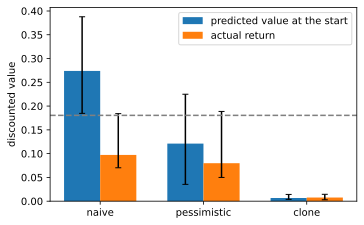

In [11]:
names = list(results)
x, w = np.arange(len(names)), 0.35
d2l.set_figsize((5.5, 3.5))
for i, side in enumerate(['predicted value at the start', 'actual return']):
    vals = np.array([results[k][i] for k in names])
    med = np.median(vals, axis=1)
    d2l.plt.bar(x + w * i, med, w, label=side,
                yerr=[med - vals.min(axis=1), vals.max(axis=1) - med],
                capsize=3)
d2l.plt.axhline(V_star[0], ls='--', color='gray')
d2l.plt.xticks(x + w / 2, names)
d2l.plt.ylabel('discounted value')
d2l.plt.legend();

Across the fifteen datasets, naive offline Q-learning predicts a start-state value between $0.185$ and $0.388$, with median $0.274$. The true optimum is $0.180$, so every prediction exceeds the value achievable by any policy in this environment. Yet the learned greedy policies have a median return of only $0.097$. Comparing predicted value with realized return is a standard diagnostic in offline reinforcement learning; with deep networks and continuous actions, the discrepancy can be much larger [@Levine.Kumar.Tucker.ea.2020; @Fujimoto.Meger.Precup.2019].

Behavior cloning predicts a median value of $0.007$ and obtains $0.008$. It is well calibrated but reproduces the poor random behavior. Naive offline Q-learning produces policies with returns roughly an order of magnitude larger, even though it substantially overestimates their values.

These two comparisons measure different properties. Comparison with behavior cloning asks whether offline learning improves on the data-collection policy. Comparison of predicted and realized return asks whether its value estimates are calibrated. Naive Q-learning succeeds on the first criterion and fails on the second.

## Pessimism

### The Count-Based Penalty $\kappa/\sqrt{n}$

The largest errors occur at poorly supported state--action pairs. We therefore subtract $\kappa/\sqrt{n(s,a)}$ both inside the bootstrap maximum and from the final values, where $n(s,a)$ is the pair's count in the dataset. This is the penalty implemented by `offline_q` when `kappa > 0`.

The $1/\sqrt{n}$ dependence is motivated by the sampling error of an $n$-sample average and resembles the UCB radius $\kappa\sqrt{\log t/n}$ from that section. Here it is a heuristic shrinkage term, not a confidence interval with a coverage guarantee. We evaluate this shape by pooling the counts and errors against $Q^*$ from the fifteen naive runs:

659 supported live pairs over 15 datasets: error min 0.000, median 0.094, max 0.458
kappa centering kappa/sqrt(n) on the cloud: 0.57
residual error at n > 100: median 0.077


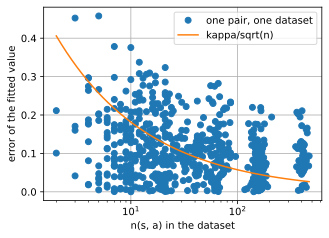

In [12]:
support, error = [], []
for batch, Q in zip(datasets, fits):
    c = np.zeros((16, 4))
    np.add.at(c, (batch.obs, batch.act), 1)
    support.append(c[live].ravel())
    error.append(np.abs(Q - Q_star)[live].ravel())
support, error = np.concatenate(support), np.concatenate(error)
n, e = support[support > 0], error[support > 0]
kappa_fit = np.median(e * np.sqrt(n))
print(f'{len(n)} supported live pairs over {num_datasets} datasets: error '
      f'min {e.min():.3f}, median {np.median(e):.3f}, max {e.max():.3f}')
print(f'kappa centering kappa/sqrt(n) on the cloud: {kappa_fit:.2f}')
print(f'residual error at n > 100: median {np.median(e[n > 100]):.3f}')
grid = np.logspace(np.log10(n.min()), np.log10(n.max()), 50)
d2l.plot([n, grid], [e, kappa_fit / np.sqrt(grid)],
         xlabel='n(s, a) in the dataset', ylabel='error of the fitted value',
         legend=['one pair, one dataset', 'kappa/sqrt(n)'],
         xscale='log', fmts=('o', '-'), figsize=(5, 3.5))

The fitted scale is $\kappa=0.57$, but it only centers the curve on these fifteen datasets. The errors range from $0.000$ to $0.458$, with median $0.094$, and do not follow a clean $1/\sqrt{n}$ law. Even above 100 visits, their median remains $0.077$. Maximization bias, the constant step size $\alpha$, and incomplete convergence can all produce this residual, which additional samples do not necessarily remove.

Among the 660 state--action-pair and dataset combinations, one pair is unobserved and receives the $n=0$ treatment defined above. We use the milder value $\kappa=0.1$, about one fifth of the descriptive fit. Exercise 4 explores both smaller and larger penalties.

The example combines four distinct difficulties. *Support failure* occurs when an action or region is absent from the data. *Statistical uncertainty* remains when counts are finite and is the component approximated by $1/\sqrt{n}$. *Bootstrapped extrapolation* propagates errors through function approximation and is largely absent from this tabular experiment. Finally, *model selection* requires choosing $\kappa$ without the online evaluation that the setting forbids.

### Optimism Online, Pessimism Offline

Online exploration and offline learning use similar count-dependent terms with opposite signs. UCB adds $\kappa\sqrt{\log t/n}$ to favor actions with little data, whereas offline pessimism subtracts $\kappa/\sqrt{n}$ to avoid relying on them. These terms express the same qualitative dependence on support but are not the same statistical quantity: the online bonus includes $\log t$, and the two methods tune their scales for different objectives.

The difference follows from feedback. Online, an optimistic action can be selected and its estimate corrected with new observations; optimism can therefore drive exploration. Offline, no new observation can correct an optimistic error, so uncertainty is handled conservatively.

### Calibration after Pessimism

The pessimistic estimate has median $0.121$, down from $0.274$, and exceeds the true optimum on only two of the fifteen datasets. Its range is $0.035$ to $0.225$. The policy itself is not better: it outperforms the naive policy on only four datasets, and its median return is $0.080$ rather than $0.097$. Pessimism has instead reduced the discrepancy between predicted and realized performance. More sophisticated versions of this conservative principle are common in modern offline reinforcement learning [@Levine.Kumar.Tucker.ea.2020].

## Beyond the Gridworld

### Constraining the Policy, the Values, or Both

Exact counts are unavailable in continuous state and action spaces, but deep offline methods retain the same two responses: constrain the policy to supported actions or reduce values outside the data distribution. Batch-constrained Q-learning takes the first approach and restricts the learned policy to actions represented in the dataset [@Fujimoto.Meger.Precup.2019]. Its tabular analogue replaces the graded penalty in `offline_q` with a hard support constraint:

In [13]:
def support_q(batch, num_sweeps, alpha, gamma, seed=0):
    """offline_q with the graded penalty replaced by a hard support rule."""
    Q, counts = np.zeros((16, 4)), np.zeros((16, 4))
    np.add.at(counts, (batch.obs, batch.act), 1)
    rng = np.random.default_rng(seed)
    for _ in range(num_sweeps):
        for i in rng.permutation(len(batch)):
            s, a, s2 = batch.obs[i], batch.act[i], batch.next_obs[i]
            v2 = np.where(counts[s2] > 0, Q[s2], 0.0).max()   # changed line 1
            Q[s, a] += alpha * (batch.rew[i] + gamma
                                * (1 - batch.term[i]) * v2 - Q[s, a])
    return np.where(counts > 0, Q, 0.0)                       # changed line 2

assert np.array_equal(support_q(data, num_sweeps, alpha, gamma), fits[0])
print('on this dataset the support rule reproduces the naive run, '
      'bit for bit')

on this dataset the support rule reproduces the naive run, bit for bit


On this dataset, the hard support constraint reproduces naive Q-learning exactly. Values start at zero, rewards are nonnegative, and every available pair has at least seven observations. An unobserved action therefore cannot obtain a larger value than an observed one, and no available action is actually unobserved. The failure here is variation in the amount of support, which a binary rule cannot distinguish but $\kappa/\sqrt{n}$ can.

In continuous action spaces, almost every exact action is absent from the dataset, so support constraints become more important. Conservative Q-learning instead penalizes the values of out-of-distribution actions [@Kumar.Zhou.Tucker.ea.2020]. Implicit Q-learning avoids querying unseen actions by backing up an upper expectile of values observed in the dataset [@Kostrikov.Nair.Levine.2022]. TD3+BC adds a behavior-cloning term to an off-policy actor and provides a strong simple baseline [@Fujimoto.Gu.2021].

Most practical offline methods constrain the policy, the value estimates, or both.

### Sequence Modeling without Bootstrapping

Decision Transformer avoids bootstrapping by treating each trajectory as a sequence of returns-to-go, states, and actions [@Chen.Lu.Rajeswaran.ea.2021]. An autoregressive model is trained by supervised prediction and, at test time, is conditioned on a desired return. It uses neither a value function nor a maximization target. On standard benchmarks, this approach matches strong value-based offline methods. However, a later study found that a small return-conditioned network trained by ordinary supervised learning recovers much of the performance, so the contribution of the sequence architecture remains unsettled. that section returns to this connection for language models.

### Offline Model Selection

The preceding comparisons use simulator rollouts, which are unavailable in a genuine offline deployment. Selecting $\kappa$, the number of sweeps, or one of several learned policies requires estimating counterfactual performance from logged data. Importance-weighted estimators for this task inherit the high variance described in that section when the evaluated policy differs from the behavior policy [@Levine.Kumar.Tucker.ea.2020].

Reliable offline model selection remains an open problem. Exercise 6 examines what can be inferred when direct evaluation rollouts are unavailable.

## Summary

On-policy updates estimate expectations under the current policy; importance ratios permit limited correction for older policies. Q-learning is off-policy because its Bellman target does not depend on the data-collection policy, whereas SARSA evaluates the behavior policy itself. Offline reinforcement learning applies off-policy updates to a fixed dataset. Without interaction, overestimated actions outside the dataset's support cannot be tested and corrected. A count-based pessimistic penalty reduces these estimates but does not guarantee a better policy. Deep offline methods likewise constrain policies, values, or both, and model selection without online evaluation remains difficult.

**Experimental scope.** The SARSA comparison uses one seed and one exploration rate. The offline experiment reports fifteen independently collected datasets and 500 evaluation episodes per learned policy. Naive offline Q-learning predicts values above the known optimum on every dataset. Pessimism substantially improves calibration but does not improve median return in this example. Exact optimal values are available only because the experiment uses a small known MDP.

## Exercises

1. [short-code] *Does the clone win?* Add a behavior-cloning arm on each of
   the three dataset types of exercise 3 and report which arm wins on each;
   explain the pattern in terms of the behavior policy's quality.
1. [short-code] *More data, or better data.* Rerun the offline experiment with
   datasets of 100, 500 and 2000 episodes. How do the predicted and the actual
   values move? Does more random data close the gap by itself, and if not, what
   is it that more data does not buy?
1. [short-code] *Where the data comes from.* Build three datasets of 500
   episodes each: from a uniform random policy, from a near-optimal policy with
   $\epsilon = 0.1$, and from a fifty-fifty mixture. Run naive offline
   Q-learning on each and report predicted value and actual return. Which
   dataset yields the best policy, which the best-calibrated prediction, and
   why is the expert-only dataset not the winner?
1. [short-code] *How much pessimism.* Sweep $\kappa$ over
   $\{0.02, 0.1, 0.3, 1.0\}$. Describe both failure directions: what happens
   when pessimism is too weak, and what happens when it is too strong? Plot
   predicted value and actual return on the same axes and identify the
   crossing.
1. [conceptual] *Constrain the values, or constrain the policy.* The text's
   support rule reproduced the naive run exactly, and the argument for why
   leaned on zero initialization and nonnegative rewards. Construct a behavior
   policy, or an initialization, for which the support rule and the count
   penalty genuinely differ, and say which of the two you would trust with a
   dataset gathered by a safety-conscious human operator.
1. [conceptual] *What you cannot measure offline.* Our diagnostic compared the
   predicted value with the actual return of the greedy policy, which required
   rolling the policy out in the simulator. A real offline deployment cannot do
   that. Name what you would use instead, say what each of those estimators
   needs that our setting supplies for free, and explain why the whole family
   inherits a version of the variance problem of that section.

[Discussions](https://d2l.discourse.group/)